In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

In [2]:
!pip install ruwordnet
!ruwordnet download

downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [3]:
from ruwordnet import RuWordNet
# Загружаем RuWordNet (русская семантическая сеть)
wn = RuWordNet()

Получаем все значения (senses) слова "замок" из RuWordNet
Для каждого значения выводим соответствующий синсет (набор синонимичных слов)
Слово "замок" имеет два значения:
1. средневековый замок (крепость)
2. замок для запирания (механизм)

In [ ]:

for sense in wn.get_senses('замок'):
    print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [ ]:
# Получаем гиперонимы (более общие понятия) для первого значения слова "за'мок"
# В данном случае это будет средневековый за'мок (крепость)
wn.get_senses('замок')[0].synset.hypernyms

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [ ]:
# Получаем гиперонимы (более общие понятия) для первого значения слова "замо'к"
wn.get_senses('замок')[1].synset.hypernyms

[Synset(id="109543-N", title="ЗАПОР, ЗАПОРНОЕ УСТРОЙСТВО")]

In [11]:
# Получаем гиперонимы (более общие понятия) для слова "спаржа"
# Берем первое значение слова и получаем его синсет, затем находим гиперонимы
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [13]:
# Получаем первое значение слова "спаржа" через get_senses()
# Затем получаем его синсет (набор синонимичных слов)
# Из гиперонимов (более общих понятий) этого синсета берем первый
# В данном случае это будет категория "ОВОЩИ" (id="348-N")
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0]
veg

Synset(id="348-N", title="ОВОЩИ")

In [14]:
# Получаем список гипонимов (более конкретных понятий) для категории "ОВОЩИ"
# Это даст нам все виды овощей, которые являются подкатегориями общего понятия "ОВОЩИ"
# В результате мы получим согипонимы (слова одного уровня иерархии) для слова "спаржа"
veg.hyponyms

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

In [8]:
wn.get_senses('авокадо') # значения слова "авокадо"

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

Другие виды отношений

In [19]:
# Получаем домены (области применения/категории) для первого значения слова "мяч"
# domains возвращает список доменов, к которым относится данное значение слова
wn.get_senses('мяч')[0].synset.domains

[Synset(id="109383-N", title="ИГРА (РАЗВЛЕЧЕНИЕ)"),
 Synset(id="1622-N", title="СПОРТ")]

In [20]:
import random

# Выбираем случайные 10 элементов из списка domain_items первого значения слова "музыка"
# domain_items содержит все элементы, относящиеся к данному домену (области)
# Выводим каждый элемент в отдельной строке
for item in random.sample(wn['музыка'][0].synset.domain_items, 10):
    print(item)

Synset(id="113187-A", title="МЕЛОМАН")
Synset(id="132691-N", title="МОДУЛИРОВАНИЕ, СМЕНА ТОНАЛЬНОСТИ")
Synset(id="108114-N", title="ГОРН (МУЗЫКАЛЬНЫЙ ИНСТРУМЕНТ)")
Synset(id="117333-N", title="ПОДЫГРАТЬ (АККОМПАНИРОВАТЬ)")
Synset(id="108927-N", title="СОПРАНО")
Synset(id="1431-A", title="МУЗЫКАНТ")
Synset(id="145868-N", title="НАСТРОЙКА МУЗЫКАЛЬНОГО ИНСТРУМЕНТА")
Synset(id="145893-A", title="ОПЕРНОЕ ИСКУССТВО")
Synset(id="112216-N", title="ДЖАЗИСТ")
Synset(id="149370-A", title="ЦЕРКОВНЫЙ РЕГЕНТ")


In [21]:
# Получаем список всех элементов, относящихся к домену СПОРТ
# domains[1] - это второй домен слова "мяч" (СПОРТ)
# domain_items возвращает все элементы, которые относятся к этому домену
wn.get_senses('мяч')[0].synset.domains[1].domain_items

[Synset(id="10014-A", title="ТЕННИСНЫЙ КОРТ"),
 Synset(id="10014-N", title="ТЕННИСНЫЙ КОРТ"),
 Synset(id="10040-A", title="ГАНДБОЛ"),
 Synset(id="10040-N", title="ГАНДБОЛ"),
 Synset(id="10244-A", title="АЛЬПИНИСТ"),
 Synset(id="10244-N", title="АЛЬПИНИСТ"),
 Synset(id="10267-N", title="ГОЛЬФ"),
 Synset(id="107172-N", title="СПОРТИВНАЯ ДИСТАНЦИЯ"),
 Synset(id="108790-N", title="КАНОЭ"),
 Synset(id="109299-N", title="СПОРТИВНАЯ БОРЬБА"),
 Synset(id="109300-N", title="КАРАТЭ"),
 Synset(id="109397-A", title="БЕЙСБОЛ"),
 Synset(id="109397-N", title="БЕЙСБОЛ"),
 Synset(id="109400-A", title="РЕГБИ"),
 Synset(id="109400-N", title="РЕГБИ"),
 Synset(id="109403-A", title="ХОККЕЙ НА ЛЬДУ"),
 Synset(id="109403-N", title="ХОККЕЙ НА ЛЬДУ"),
 Synset(id="109404-A", title="ШАШКИ"),
 Synset(id="109404-N", title="ШАШКИ"),
 Synset(id="109524-A", title="ГОРОДКИ"),
 Synset(id="109524-N", title="ГОРОДКИ"),
 Synset(id="109648-N", title="ДЖИУ-ДЖИТСУ"),
 Synset(id="109649-A", title="ДЗЮДО"),
 Synset(id="109649-N

In [22]:
# Получаем список меронимов (частей) для первого значения слова "автомобиль"
# meronyms возвращает список частей, из которых состоит автомобиль
wn.get_senses('автомобиль')[0].synset.meronyms # части автомобиля

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"),
 Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"),
 Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"),
 Synset(id="108798-N", title="КАПОТ МАШИНЫ")]

In [23]:
# Получаем список холонимов (целых) для первого значения слова "страница"
# holonyms возвращает список объектов, частью которых является страница
wn.get_senses('страница')[0].synset.holonyms 

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"),
 Synset(id="5820-N", title="ТЕТРАДЬ")]

In [24]:
# Получаем список классов, экземпляром которых является "москва-река"
# classes возвращает список классов, к которым относится данное значение слова
wn['москва-река'][0].synset.classes

[Synset(id="136791-N", title="РЕКИ РОССИЙСКОЙ ФЕДЕРАЦИИ")]

In [25]:
# Получаем список экземпляров (instances) для первого значения слова "областной центр"
# instances возвращает список конкретных объектов, которые являются экземплярами данного класса
wn['областной центр'][0].synset.instances

[Synset(id="100355-N", title="АСТРАХАНЬ"),
 Synset(id="101407-N", title="КОСТРОМА"),
 Synset(id="102587-N", title="САРАТОВ"),
 Synset(id="105766-N", title="ЮЖНО-САХАЛИНСК"),
 Synset(id="102937-N", title="ТЮМЕНЬ"),
 Synset(id="102849-N", title="ТВЕРЬ"),
 Synset(id="102325-N", title="ОРЕНБУРГ"),
 Synset(id="101352-N", title="КИРОВ (ВЯТКА)"),
 Synset(id="100628-N", title="ВОЛГОГРАД"),
 Synset(id="102104-N", title="МУРМАНСК"),
 Synset(id="101001-N", title="ИВАНОВО"),
 Synset(id="100244-N", title="БЛАГОВЕЩЕНСК"),
 Synset(id="103066-N", title="ЧЕЛЯБИНСК"),
 Synset(id="102903-N", title="ТОМСК"),
 Synset(id="102373-N", title="ПЕНЗА"),
 Synset(id="102220-N", title="НОВОСИБИРСК"),
 Synset(id="102521-N", title="РОСТОВ-НА-ДОНУ"),
 Synset(id="100438-N", title="БЕЛГОРОД"),
 Synset(id="102207-N", title="НОВГОРОД"),
 Synset(id="100484-N", title="БРЯНСК"),
 Synset(id="100650-N", title="ВОЛОГДА"),
 Synset(id="101142-N", title="КАЛУГА"),
 Synset(id="100328-N", title="АРХАНГЕЛЬСК"),
 Synset(id="103153-N",

In [26]:
# Получаем список предпосылок (premises) для первого значения слова "убить"
# premises возвращает список предпосылок, которые могут привести к данному действию
wn['убить'][0].synset.premises

[]

In [27]:
# Получаем список следствий (conclusions) для первого значения слова "завоевать"
# conclusions возвращает список возможных следствий данного действия
wn['завоевать'][0].synset.conclusions

[Synset(id="106961-V", title="СОРЕВНОВАНИЕ, СОСТЯЗАНИЕ")]

In [28]:
# Получаем список причин (causes) для первого значения слова "устать"
# causes возвращает список действий/состояний, которые могут привести к усталости
wn['устать'][0].synset.causes

[Synset(id="114599-V", title="УТОМИТЬ")]

In [29]:
# Получаем список эффектов (последствий) для первого значения слова "утомить"
# effects возвращает список возможных последствий/результатов данного действия
wn['утомить'][0].synset.effects

[Synset(id="117320-V", title="УТОМИТЬСЯ, УСТАТЬ")]

In [30]:
# Перебираем частеречные синонимы первого синсета слова "убить"
for ss in wn['убить'][0].synset.pos_synonyms:
    # Получаем список значений (senses) для каждого синсета-синонима
    senses = ss.senses
    # Выводим каждое значение
    for s in senses:
        print(s)

Sense(id="4628-N-113272", name="УБИЙСТВО")
Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ")
Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО")
Sense(id="4628-N-193509", name="МОКРУХА")
Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО")
Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО")
Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА")
Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")


In [31]:
# Получаем список всех значений (senses) для всех частеречных синонимов первого синсета слова "убить"
# Используем list comprehension для более компактной записи:
# - внешний цикл перебирает синсеты-синонимы (ss)
# - внутренний цикл перебирает значения (s) для каждого синсета
[s for ss in wn['убить'][0].synset.pos_synonyms for s in ss.senses]

[Sense(id="4628-N-113272", name="УБИЙСТВО"),
 Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ"),
 Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО"),
 Sense(id="4628-N-193509", name="МОКРУХА"),
 Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО"),
 Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО"),
 Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА"),
 Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")]

In [32]:
# Получаем список антонимов (противоположных по значению слов) для первого значения слова "быстрый"
wn['быстрый'][0].synset.antonyms

[Synset(id="118957-A", title="МЕДЛЕННЫЙ, НЕБЫСТРЫЙ")]

Отношения между смыслами (senses), а не между сенсетами(synsets)

In [33]:
# Получаем список фраз, в которых встречается слово "быстрый"
# Метод phrases возвращает список устойчивых словосочетаний/фраз, содержащих данное слово
wn['быстрый'][0].phrases

[Sense(id="102679-N-129996", name="РЕКА БЫСТРАЯ"),
 Sense(id="8930-N-117128", name="БЫСТРОЕ ПИТАНИЕ"),
 Sense(id="9241-N-118631", name="БЫСТРЫЕ ШАХМАТЫ")]

In [34]:
# Получаем список слов, входящих в первый синсет словосочетания "послужной список"
wn['послужной список'][0].words

[Sense(id="106989-N-153921", name="СПИСОК")]

In [35]:
# Получаем список производных слов от слова "красный"
# Метод derivations возвращает список слов, образованных от данного слова
wn['красный'][0].derivations

[Sense(id="109437-A-205240", name="КРАСНОВАТЫЙ"),
 Sense(id="109437-N-140855", name="КРАСНОТА"),
 Sense(id="110417-N-702073", name="ПОКРАСНЕНИЕ"),
 Sense(id="110417-V-140852", name="КРАСНЕТЬ"),
 Sense(id="110417-V-147981", name="ПОКРАСНЕТЬ"),
 Sense(id="110417-V-182793", name="ЗАКРАСНЕТЬ"),
 Sense(id="111004-V-140852", name="КРАСНЕТЬ"),
 Sense(id="111004-V-182793", name="ЗАКРАСНЕТЬ")]

Предсказание гиперонимов

In [36]:
import numpy as np 
import compress_fasttext  # библиотека для сжатия моделей fasttext
# compress_fasttext позволяет уменьшить размер моделей fasttext без значительной потери качества

from collections import Counter  # класс для подсчета частоты элементов в последовательности
from sklearn.neighbors import KDTree  # структура данных для эффективного поиска ближайших соседей в многомерном пространстве
# KDTree разбивает k-мерное пространство на отдельные фрагменты для оптимизации поиска

import matplotlib.pyplot as plt  
%matplotlib inline 

In [37]:
# загружаем fasttext модель, которая уже была сжата заранее
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [38]:
# Функция для векторизации текста - преобразует текст в числовой вектор
def vectorize(text):
    # Получаем векторы для каждого слова длиной >= 3 символов и находим их среднее
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0)
    # Нормализуем вектор (приводим к единичной длине)
    vec /= sum(vec**2) ** 0.5
    return vec

# Функция для преобразования расстояния между векторами в вес голоса
def distance2vote(d, a=3, b=5):
    # Вычисляем базовое сходство на основе расстояния
    sim = np.maximum(0, 1 - d**2/2)
    # Комбинируем экспоненциальное затухание и степенное взвешивание
    return np.exp(-d**a) * sim **b

Text(0.5, 1.0, 'Функция взвешивания соседей')

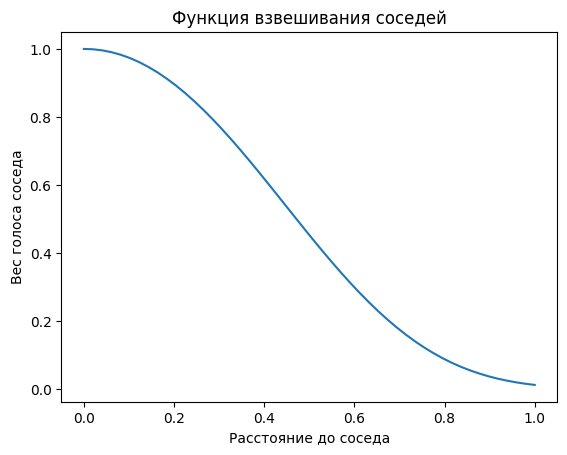

In [39]:
# Создаем массив из 50 равномерно распределенных чисел от 0 до 1
x = np.linspace(0, 1) 

# Строим график функции distance2vote, которая преобразует расстояние между векторами в вес голоса
# По оси X - расстояние между векторами (от 0 до 1)
# По оси Y - вес голоса соседа (оценка семантической близости)
plt.plot(x, distance2vote(x))

# Добавляем подписи к осям и заголовок графика
plt.xlabel('Расстояние до соседа')  # Подпись оси X
plt.ylabel('Вес голоса соседа')     # Подпись оси Y
plt.title('Функция взвешивания соседей')  # Заголовок графика

In [40]:
# Импортируем библиотеку tqdm для отображения прогресс-бара
# tqdm - основная функция для создания прогресс-бара
# trange - специальная версия tqdm для работы с range()
from tqdm.auto import tqdm, trange

c:\Users\79040\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# Инициализируем пустые списки для хранения слов, их векторных представлений и идентификаторов синсетов
words, vectors, synset_ids = [], [], []

# Перебираем все синсеты в тезаурусе с отображением прогресса
for synset in tqdm(wn.synsets):
    # Пропускаем все части речи кроме глаголов
    if synset.part_of_speech != 'V':
        continue
    
    # Для каждого синсета обрабатываем все его смыслы
    for sense in synset.senses:
        # Сохраняем слово
        words.append(sense.name)
        # Создаем векторное представление слова с помощью функции vectorize
        vectors.append(vectorize(sense.name))
        # Сохраняем идентификатор синсета
        synset_ids.append(synset.id)

# Объединяем все векторы в единую матрицу
# Каждая строка матрицы - векторное представление одного слова
vectors = np.stack(vectors)

100%|██████████| 59905/59905 [12:20<00:00, 80.89it/s]    


In [42]:
# Создаем KD-дерево для эффективного поиска ближайших соседей в векторном пространстве
# KD-дерево позволяет быстро находить k ближайших точек к заданной точке
# В нашем случае точки - это векторные представления слов
tree = KDTree(vectors)

In [43]:
# Создаем список из 10 случайных массивов размерности 3x4
# np.random.randn() генерирует случайные числа из нормального распределения
arrays = [np.random.randn(3, 4) for _ in range(10)] 

# Выводим первый массив для примера
arrays[0]

# Объединяем все массивы в один многомерный массив
# np.stack() складывает массивы по указанной оси (axis=0)
# Результат будет иметь размерность (10, 3, 4):
# - 10 массивов
# - каждый массив размером 3x4
np.stack(arrays, axis=0).shape

(10, 3, 4)

In [44]:
tree = KDTree(vectors) 

In [45]:
# Создаем счетчик для подсчета голосов за каждый гипероним
votes = Counter() 

# Находим 100 ближайших соседей для вектора слова "кудахтать" в векторном пространстве
# dists - расстояния до соседей, ids - их индексы
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100)

# Для каждого найденного соседа
for idx, distance in zip(ids[0], dists[0]):
    # Получаем все гиперонимы синсета этого соседа
    for hyper in wn[synset_ids[idx]].hypernyms:
        # Увеличиваем счетчик для данного гиперонима на значение, 
        # зависящее от расстояния до соседа (чем ближе сосед, тем больше голос)
        votes[hyper.id] += distance2vote(distance)
    
    # Выводим слово и список его гиперонимов для отладки
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms])

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['БОРМОТАТЬ']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ РУКОЙ, ЗУБАМИ, ОРУДИЕМ']
БРАТЬСЯ ['П

In [46]:
#10 наиболее семантически близких к данному слову гиперонимов
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


Найди лишнее

Какое из слов ДИВАН, ШКАФ, ЛАМПА, СТОЛ лишнее?

In [47]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    """Возвращает все гиперонимы слова word и их расстояния"""
    # Получаем список всех синсетов для данного слова
    front = [sense.synset for sense in wn.get_senses(word)]
    # Словарь для хранения уровней гиперонимов
    levels = {}
    
    # Проходим по уровням иерархии гиперонимов
    for level in range(max_level):
        if not front:  # Если больше нет гиперонимов для обработки
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                # Сохраняем уровень гиперонима (чем меньше уровень, тем ближе к исходному слову)
                levels[synset.id] = level
                # Добавляем гиперонимы текущего синсета для следующей итерации
                new_front.extend(synset.hypernyms)
        front = new_front
    return levels

def get_closest_common(levels1, levels2):
    """ Find the closest common hypernym and sum of distances to it"""
    """Возвращает самый близкий общий гипероним и сумму расстояний до него"""
    result = None
    result_distance = math.inf  # Инициализируем максимально возможным расстоянием
    
    # Ищем общие гиперонимы и выбираем ближайший
    for id, distance in levels1.items():
        if id in levels2:  # Если гипероним есть в обоих словах
            total = distance + levels2[id]  # Суммируем расстояния до общего гиперонима
            if total < result_distance:  # Если нашли более близкий общий гипероним
                result_distance = total
                result = id
    return result, result_distance

In [48]:
# Создаем список слов для сравнения
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']

# Выводим заголовок таблицы - имена слов
print('\t\t', '\t'.join(words))

# Для каждого слова в списке
for w1 in words:
    # Выводим текущее слово в начале строки
    print(w1, end='\t')
    # Для каждого слова в списке (включая текущее)
    for w2 in words:
        # Находим ближайший общий гипероним и расстояние до него
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        # Выводим расстояние
        print(d, end='\t\t')
    # Переходим на новую строку после обработки всех пар с текущим словом
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


In [49]:
# Находим ближайший общий гипероним между словами "лампа" и "шкаф"
# get_all_hypernyms() возвращает словарь с расстояниями до всех гиперонимов
# get_closest_common() находит ближайший общий гипероним и сумму расстояний до него
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
# Выводим расстояние до общего гиперонима, его id и название
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [50]:
# Выводим информацию о гиперонимах слова "лампа":
# k - id гиперонима
# v - расстояние от слова "лампа" до этого гиперонима
# wn[k] - сам синсет гиперонима с его названием
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


### Word Sense Disambiguation (WSD)

In [51]:
зАмок или замОк?

Object `замОк` not found.


Примитивный алгоритм: для каждого значения находим синонимы и проверяем, какие ближе по fasttext-эмбеддингу к словам контекста.

In [52]:
!pip install razdel

In [53]:
import razdel # библиотека для токенизации

In [74]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [75]:
def disambiguate(word, context):
    # Получаем список синсетов (значений) для заданного слова
    candidates = [s.synset for s in wn[word]]
    
    # Токенизируем контекст и создаем вектор для всего текста, исключая целевое слово
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word))
    
    # Для каждого синсета-кандидата создаем вектор на основе его синонимов
    candidate_vectors = [
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates
    ]
    
    # Вычисляем косинусное сходство между вектором контекста и векторами кандидатов
    scores = [np.dot(text_vector, v) for v in candidate_vectors]
    
    # Возвращаем словарь {сходство: синсет} для каждого кандидата
    return dict(zip(scores, candidates))

In [76]:
disambiguate(word, context)

TypeError: vectorize() missing 1 required positional argument: 'ft'

In [77]:
# Функция для векторизации текста (среднее по словам, исключая короткие)
def vectorize(text, ft):
    vecs = [ft[word] for word in text.lower().split() if len(word) >= 3 and word in ft]
    if not vecs:
        return np.zeros(ft.vector_size)
    vec = np.mean(vecs, axis=0)
    return vec / np.linalg.norm(vec)

In [95]:
# Функция для определения правильного смысла слова в контексте
def disambiguate(word, context, wn, ft):
    candidates = [sense.synset for sense in wn[word]]
    # Векторизуем контекст (без самой слова)
    context_tokens = [t.text for t in razdel.tokenize(context) if t.text.lower() != word.lower()]
    context_vector = vectorize(' '.join(context_tokens), ft)

    scores = {}
    for synset in candidates:
        # Векторизуем все синонимы синонима
        synonyms = ' '.join(sense.name for sense in synset.senses)
        synset_vector = vectorize(synonyms, ft)
        # Косинусное сходство между контекстом и синонимами
        score = np.dot(context_vector, synset_vector)
        scores[synset] = score

    # Выбираем смысл с максимальным баллом
    best_sense = max(scores, key=scores.get)
    return best_sense, scores[best_sense]

Примеры

In [96]:
# Пример использования
context = "Печень является важным органом для детоксикации."
word = "орган"

In [97]:
# Загружаем сжатую модель FastText (векторное представление слов)
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [98]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ОРГАН ЖИВОГО ОРГАНИЗМА, оценка: 0.7052275534581903


In [99]:
# Пример использования
context = "В филармонию принесли орган."
word = "орган"

In [100]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ОРГАН (МУЗЫКАЛЬНЫЙ ИНСТРУМЕНТ), оценка: 0.480552325118858


*Видно, что замОк для запирания - более вероятен

In [101]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [102]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ЗАМОК ДЛЯ ЗАПИРАНИЯ, оценка: 0.5531963236259403


*В данном случае более вероятен зАмок